<a href="https://colab.research.google.com/github/anand57577-lab/Garbage_Classification_CNN_Model/blob/main/DL_Garbage_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!unzip Garbage_dataset.zip

Archive:  Garbage_dataset.zip
  inflating: dataset-resized/cardboard/cardboard1.jpg  
  inflating: dataset-resized/cardboard/cardboard10.jpg  
  inflating: dataset-resized/cardboard/cardboard100.jpg  
  inflating: dataset-resized/cardboard/cardboard101.jpg  
  inflating: dataset-resized/cardboard/cardboard102.jpg  
  inflating: dataset-resized/cardboard/cardboard103.jpg  
  inflating: dataset-resized/cardboard/cardboard104.jpg  
  inflating: dataset-resized/cardboard/cardboard105.jpg  
  inflating: dataset-resized/cardboard/cardboard106.jpg  
  inflating: dataset-resized/cardboard/cardboard107.jpg  
  inflating: dataset-resized/cardboard/cardboard108.jpg  
  inflating: dataset-resized/cardboard/cardboard109.jpg  
  inflating: dataset-resized/cardboard/cardboard11.jpg  
  inflating: dataset-resized/cardboard/cardboard110.jpg  
  inflating: dataset-resized/cardboard/cardboard111.jpg  
  inflating: dataset-resized/cardboard/cardboard112.jpg  
  inflating: dataset-resized/cardboard/cardboa

In [3]:
import tensorflow
import matplotlib.pyplot as plt
import numpy as np
import os


In [4]:
training_data = tensorflow.keras.utils.image_dataset_from_directory(
    'Garbage_data',
    validation_split = 0.2,
    subset = 'training',
    seed = 42,
    image_size = (224, 224),
    batch_size = 32
)

validation_data = tensorflow.keras.utils.image_dataset_from_directory(
    'Garbage_data',
    validation_split = 0.2,
    subset = 'validation',
    seed = 42,
    image_size  = (224,224),
    batch_size = 32
)


Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [5]:
class_names = training_data.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


**Visualization**

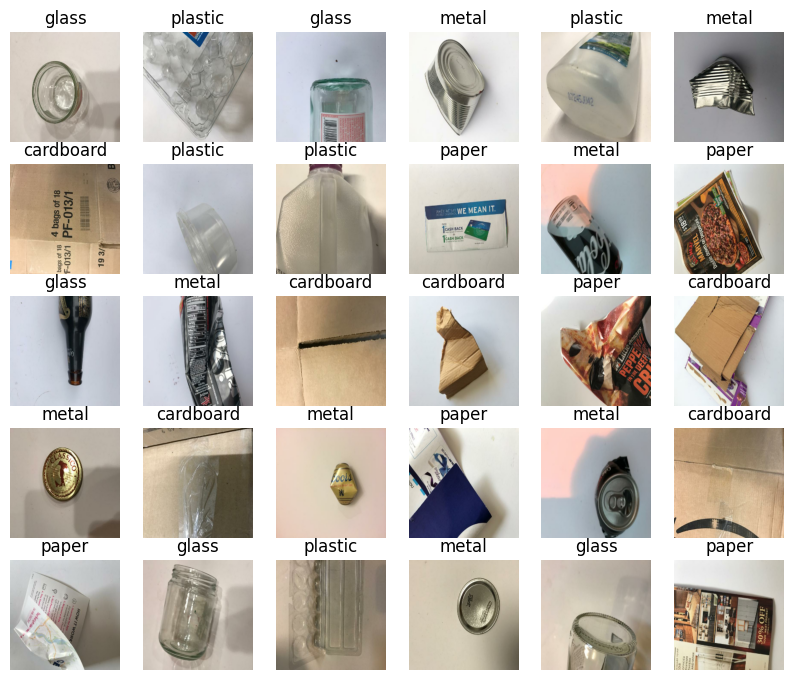

In [6]:
plt.figure(figsize = (10,10))

for images, label in training_data.take(1):
  for i in range(30):
    ax = plt.subplot(6,6 ,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(class_names[label[i]])
    plt.axis('off')

**Normailize the image**

In [7]:
normalization = tensorflow.keras.layers.Rescaling(1./255)

In [8]:
training_data = training_data.map(lambda x,y : (normalization(x), y))
validation_data  = validation_data.map(lambda x,y : (normalization(x),y))

**optimizing Data (cache() & prefetch())**

In [9]:
AUTOTUNE = tensorflow.data.AUTOTUNE

training_data = training_data.cache().prefetch(buffer_size = AUTOTUNE)
validation_data = validation_data.cache().prefetch(buffer_size = AUTOTUNE)


In [10]:
for images, labels in training_data.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense, Dropout, Flatten, Conv2D, MaxPooling2D

**CNN MODEL**

In [12]:
import tensorflow as tf

In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [14]:
model  = Sequential()

In [15]:
model.add(Input(shape = (224,224,3)))
model.add(data_augmentation)
model.add(Conv2D(
    filters = 32,
    kernel_size = (3,3),
    activation = 'relu',
))

model.add(MaxPooling2D(pool_size  = (2,2)))

model.add(Conv2D(
    filters = 64,
    kernel_size = (3,3),
    activation  ='relu'
))

model.add(MaxPooling2D(pool_size = (2,2)))

model.add(Conv2D(
    filters = 128,
    kernel_size = (3,3),
    activation = 'relu'
))

model.add(MaxPooling2D(pool_size = (2,2)))

model.add(Conv2D(
    filters = 256,
    kernel_size = (3,3),
    activation = 'relu'
))

model.add(MaxPooling2D(pool_size = (2,2)))


model.add(Flatten())

model.add(Dense(
    128,
    activation = 'relu'
))

model.add(Dropout(0.2))

model.add(Dense(
    64,
    activation = 'relu'
))

model.add(Dropout(0.2))

model.add(Dense(
    6,
    activation = 'softmax'
))

In [16]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)


In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,115,782 (19.52 MB)

 Trainable params: 5,115,782 (19.52 MB)

 Non-trainable params: 0 (0.00 B)

EARLY_ STOPING

In [21]:
early_stoping = tensorflow.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 20,
    verbose = 1,
    mode = 'auto',
    baseline = None,
    restore_best_weights = True
)

In [23]:
history = model.fit(training_data, validation_data= validation_data, epochs = 200, callbacks = [early_stoping] )

Epoch 1/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.2587 - loss: 1.6966 - val_accuracy: 0.3307 - val_loss: 1.5872
Epoch 2/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.3739 - loss: 1.5039 - val_accuracy: 0.3426 - val_loss: 1.5085
Epoch 3/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.4179 - loss: 1.4233 - val_accuracy: 0.4554 - val_loss: 1.3710
Epoch 4/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.4614 - loss: 1.3203 - val_accuracy: 0.4792 - val_loss: 1.2746
Epoch 5/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.4773 - loss: 1.3081 - val_accuracy: 0.4851 - val_loss: 1.2302
Epoch 6/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.5198 - loss: 1.2481 - val_accuracy: 0.5465 - val_loss: 1.1878
Epoch 7/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5312 - loss: 1.1668 - val_accuracy: 0.5327 - val_loss: 1.1420
Epoch 8/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.5579 - loss: 1.1781 - val_accuracy: 

In [24]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


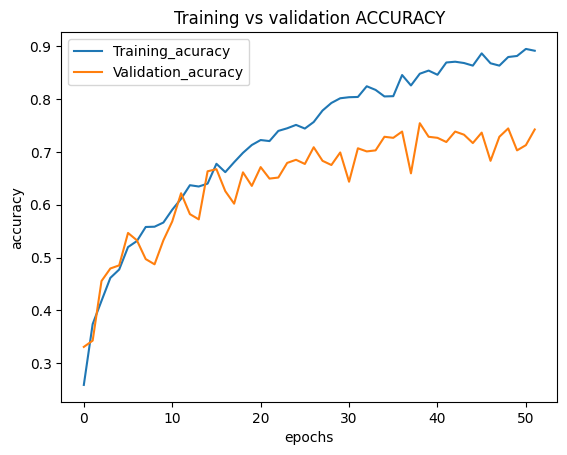

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label = 'Training_acuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation_acuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Training vs validation ACCURACY')
plt.legend()
plt.show()


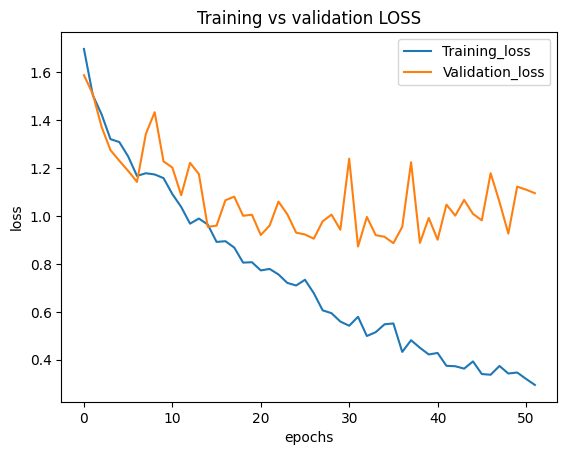

In [26]:
plt.plot(history.history['loss'], label = 'Training_loss')
plt.plot(history.history['val_loss'], label = 'Validation_loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Training vs validation LOSS')
plt.legend()
plt.show()

In [27]:
loss, accuracy = model.evaluate(validation_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7069 - loss: 0.8723


In [28]:
print("loss: ",loss)
print("Acurracy: ",accuracy)


loss:  0.8723389506340027
Acurracy:  0.7069306969642639


In [29]:
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])

print(history.history['loss'][-1])
print(history.history['val_loss'][-1])

0.8916913866996765
0.7425742745399475
0.2950179874897003
1.094806432723999


In [30]:
prediction = model.predict(validation_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


Actual Class     : glass
Predicted Class  : glass
Prediction Score : [0.0163458  0.3644488  0.20948608 0.24582888 0.15104872 0.0128418 ]


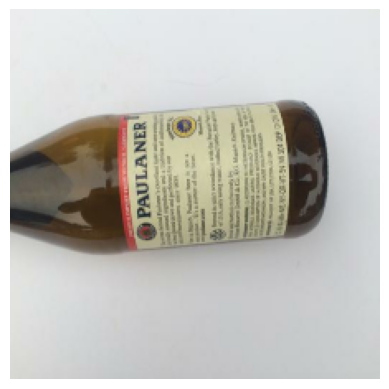

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Get one batch from validation dataset
for images, labels in validation_data.take(1):

    # Select the first image
    image = images[31]
    actual_label = labels[31].numpy()

    # Predict
    prediction = model.predict(np.expand_dims(image, axis=0), verbose=0)

    predicted_label = np.argmax(prediction)

    # Display image
    plt.imshow(image.numpy())
    plt.axis("off")

    print("Actual Class     :", class_names[actual_label])
    print("Predicted Class  :", class_names[predicted_label])
    print("Prediction Score :", prediction[0])